# Bottom-Up Proteomics Processing

In-house, Perseus-like processing of bottom-up proteomics data exported from Excel.

Pipeline: **ingest → group biological replicates into conditions → average → compare conditions
(fold change + statistics) → filter → visualize (volcano, heatmap) → annotate (subcellular
localization + function) → GO enrichment.**

All logic lives in the reusable `ms_processing` package, so a future GUI/web app can call the
exact same functions. Each config variable below maps directly to a field a GUI form would collect.

## 1. Configuration

These are the inputs a user provides at upload time:
- **Experiment type** — ABPP, AP-MS, whole proteome, ... (`ms_processing.EXPERIMENT_TYPES`).
- **Plex** — 6, 10, 16 (standard) or any custom integer; this is how many data columns to expect.
- **Data start column** — defaults to `Z`; columns before it are annotation/metadata.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

# Make the package importable when running from the notebooks/ directory.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ms_processing as msp

# --- User inputs (GUI form fields) ---------------------------------------
DATA_FILE = REPO_ROOT / "sample_data" / "sample_dataset.xlsx"
EXPERIMENT_TYPE = "ABPP"   # see msp.EXPERIMENT_TYPES
PLEX = 6                    # 6 / 10 / 16, or any custom integer
DATA_START_COLUMN = "Z"    # quantitative data begins here

print("Available experiment types:", [e.name for e in msp.EXPERIMENT_TYPES.values()])
print("Standard plexes:", msp.STANDARD_PLEXES)

Available experiment types: ['ABPP', 'AP-MS', 'Whole proteome']
Standard plexes: (6, 10, 16)


## 2. Load the Excel file

First row = header, each subsequent row = one identified protein. Columns before `Z` are
annotation/metadata; `Z` onward (width = plex) are the quantitative data columns (one per
biological replicate).

In [2]:
dataset = msp.load_dataset(
    DATA_FILE,
    experiment_type=EXPERIMENT_TYPE,
    plex=PLEX,
    data_start_column=DATA_START_COLUMN,
)

summary = dataset.describe()
print("Experiment type :", summary["experiment_type"])
print("Plex            :", summary["plex"])
print("Proteins (rows) :", summary["n_proteins"])
print("Annotation cols :", summary["n_annotation_columns"])
print("Data col range  :", summary["data_column_range"])
print("Data columns    :", summary["data_columns"])

Experiment type : ABPP
Plex            : 6
Proteins (rows) : 200
Annotation cols : 25
Data col range  : Z-AE
Data columns    : ['Treatment_1', 'Treatment_2', 'Treatment_3', 'Mock_1', 'Mock_2', 'Mock_3']


In [3]:
dataset.annotations.head()

,Accession,Gene,Description,# Unique Peptides,Filler_4,Filler_5,Filler_6,Filler_7,Filler_8,Filler_9,...,Filler_15,Filler_16,Filler_17,Filler_18,Filler_19,Filler_20,Filler_21,Filler_22,Filler_23,Filler_24
0,P00000,GENE0,Example protein,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P00001,GENE1,Example protein,19,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P00002,GENE2,Example protein,16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P00003,GENE3,Example protein,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P00004,GENE4,Example protein,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataset.data.head()

,Treatment_1,Treatment_2,Treatment_3,Mock_1,Mock_2,Mock_3
0,36760.872517,35126.901797,30460.333206,25629.772045,29517.575055,39692.392565
1,2647.240138,2447.973194,2514.415416,7614.155717,5983.522345,10934.815519
2,15545.180879,12449.581021,15812.489337,12947.793569,12272.742857,13279.989403
3,95093.026930,89886.345029,76033.507538,81393.792965,61551.868943,112827.946427
4,18824.019170,15994.220340,16000.122977,14804.085265,11006.799116,17909.016344


## 3. Assign replicate columns to conditions

Each data column is a separate biological replicate. Group the replicates belonging to the same
experimental condition. In a GUI this is a form; here it is `{condition_name: [replicate_column, ...]}`.

In [5]:
condition_map = msp.ConditionMap.from_mapping({
    "Treatment": ["Treatment_1", "Treatment_2", "Treatment_3"],
    "Mock":      ["Mock_1", "Mock_2", "Mock_3"],
})
condition_map.validate(dataset)

for cond in condition_map:
    print(f"{cond.name:>12}: {cond.n_replicates} replicates -> {list(cond.replicate_columns)}")
print("\nUnassigned data columns:", condition_map.unassigned_columns(dataset) or "(none)")

   Treatment: 3 replicates -> ['Treatment_1', 'Treatment_2', 'Treatment_3']
        Mock: 3 replicates -> ['Mock_1', 'Mock_2', 'Mock_3']

Unassigned data columns: (none)


## 4. Average protein abundance per condition

In [6]:
means = msp.condition_means(dataset, condition_map)
means[["Accession", "Gene", *condition_map.names]].head()

,Accession,Gene,Treatment,Mock
0,P00000,GENE0,34116.035840,31613.246555
1,P00001,GENE1,2536.542916,8177.497860
2,P00002,GENE2,14602.417079,12833.508610
3,P00003,GENE3,87004.293166,85257.869445
4,P00004,GENE4,16939.454162,14573.300242


## 5. Compare two conditions

Pick numerator vs denominator (e.g. Treatment vs Mock): fold change, log2(fold change), two-sided
independent t-test p-value, adjusted p-value / FDR (selectable correction), and −log10(p-value).

In [7]:
for key, label in msp.CORRECTION_METHODS.items():
    print(f"  {key:<11} {label}")
print("\nDefault:", msp.DEFAULT_CORRECTION)

  fdr_bh      Benjamini-Hochberg (FDR)
  fdr_by      Benjamini-Yekutieli (FDR)
  bonferroni  Bonferroni
  holm        Holm-Bonferroni
  sidak       Sidak

Default: fdr_bh


In [8]:
NUMERATOR = "Treatment"
DENOMINATOR = "Mock"
CORRECTION = "fdr_bh"   # Benjamini-Hochberg; change to any key above
EQUAL_VAR = True         # True = Student's t-test, False = Welch's

results = msp.compare_conditions(
    dataset, condition_map,
    numerator=NUMERATOR, denominator=DENOMINATOR,
    correction=CORRECTION, equal_var=EQUAL_VAR,
)

stat_cols = [
    f"mean_{NUMERATOR}", f"mean_{DENOMINATOR}",
    "fold_change", "log2_fold_change", "p_value", "adj_p_value", "neg_log10_p_value",
]
print("Comparison:", results.attrs["comparison"], "| correction:", results.attrs["correction"])
results[["Accession", "Gene", *stat_cols]].head(10)

Comparison: Treatment vs Mock | correction: fdr_bh


,Accession,Gene,mean_Treatment,mean_Mock,fold_change,log2_fold_change,p_value,adj_p_value,neg_log10_p_value
0,P00000,GENE0,34116.035840,31613.246555,1.079169,0.109921,0.615140,0.848469,0.211026
1,P00001,GENE1,2536.542916,8177.497860,0.310186,-1.688796,0.018009,0.065486,1.744521
2,P00002,GENE2,14602.417079,12833.508610,1.137835,0.186292,0.189120,0.450285,0.723263
3,P00003,GENE3,87004.293166,85257.869445,1.020484,0.029254,0.918209,0.971164,0.037058
4,P00004,GENE4,16939.454162,14573.300242,1.162362,0.217060,0.344064,0.618850,0.463361
5,P00005,GENE5,45184.684577,45182.622875,1.000046,0.000066,0.999668,0.999668,0.000144
6,P00006,GENE6,9557.486502,9587.204482,0.996900,-0.004479,0.982213,0.997170,0.007794
7,P00007,GENE7,17220.377926,18017.268170,0.955771,-0.065263,0.293300,0.579237,0.532689
8,P00008,GENE8,4105.830914,9174.881341,0.447508,-1.160015,0.002381,0.012534,2.623154
9,P00009,GENE9,14625.284394,16672.817795,0.877193,-0.189033,0.090368,0.244237,1.043987


## 6. Filter the results

Apply any combination of thresholds (combine with AND; leave any as `None` to skip).

In [9]:
filtered = msp.filter_results(
    results,
    max_fdr=0.05,            # keep FDR <= 0.05
    min_abs_log2fc=1.0,      # keep |log2 FC| >= 1 (>= 2-fold change)
    min_unique_peptides=2,   # keep proteins with >= 2 unique peptides
)
print(f"Proteins before filtering: {len(results)}")
print(f"Proteins after filtering : {len(filtered)}")
filtered[["Accession", "Gene", "# Unique Peptides", *stat_cols]].head(10)

Proteins before filtering: 200
Proteins after filtering : 48


,Accession,Gene,# Unique Peptides,mean_Treatment,mean_Mock,fold_change,log2_fold_change,p_value,adj_p_value,neg_log10_p_value
8,P00008,GENE8,5,4105.830914,9174.881341,0.447508,-1.160015,0.002381,0.012534,2.623154
14,P00014,GENE14,18,3871.391810,12446.004057,0.311055,-1.684758,0.000612,0.006192,3.213132
15,P00015,GENE15,19,2475.792697,5515.754657,0.448858,-1.155668,0.001064,0.007995,2.972876
19,P00019,GENE19,11,9219.847567,19832.896216,0.464877,-1.105081,0.000119,0.003376,3.922787
21,P00021,GENE21,9,4353.787486,17397.456187,0.250254,-1.998533,0.000071,0.003376,4.145730
27,P00027,GENE27,20,8555.844918,31292.117160,0.273419,-1.870817,0.003441,0.016599,2.463341
28,P00028,GENE28,14,274036.082450,97487.485826,2.810987,1.491077,0.000103,0.003376,3.985180
33,P00033,GENE33,14,20982.552454,6078.743994,3.451791,1.787345,0.005614,0.024588,2.250724
40,P00040,GENE40,4,635208.812086,185575.090000,3.422921,1.775228,0.008801,0.034512,2.055485
42,P00042,GENE42,17,9765.826228,34893.644091,0.279874,-1.837150,0.001818,0.010388,2.740440


## 7. Volcano plot

log2(fold change) vs −log10(p-value). Points beyond the fold-change and p-value cutoffs are
colored up (red) / down (blue); the top hits are labelled. Set `use_adjusted=True` to plot the
FDR instead of the raw p-value.

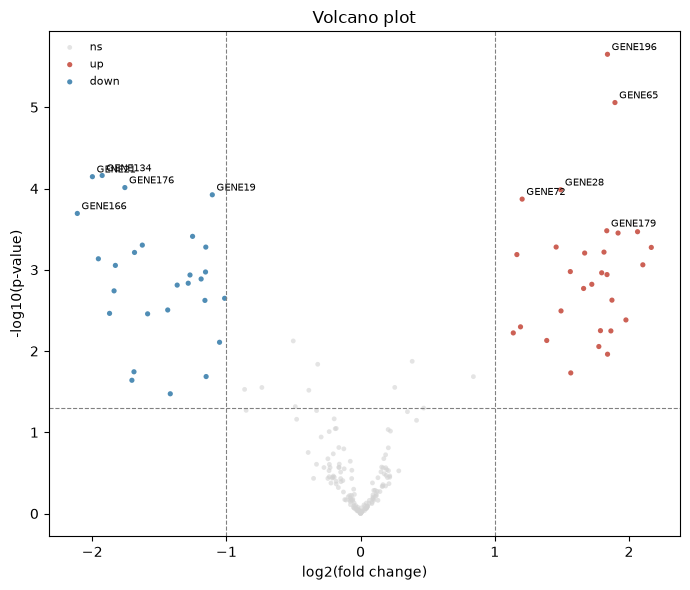

In [10]:
ax = msp.volcano_plot(
    results,
    fc_threshold=1.0,      # |log2FC| cutoff (dashed vertical lines)
    p_threshold=0.05,      # p-value cutoff (dashed horizontal line)
    use_adjusted=False,    # True -> use adjusted p-value / FDR
    label_col="Gene", n_labels=10,
)
plt.tight_layout(); plt.show()

## 8. Heatmap

Abundance across replicates for the significant proteins, z-scored per protein so relative
patterns stand out. `cluster=True` uses `seaborn.clustermap` to cluster proteins and samples.

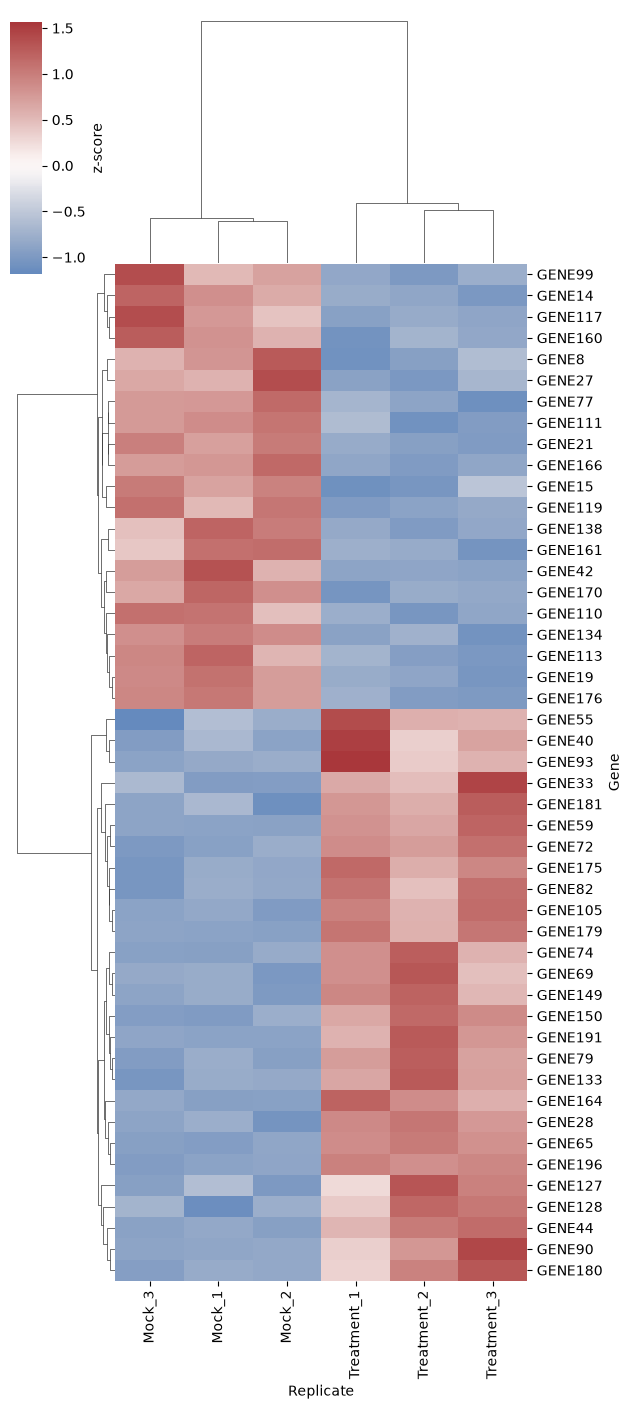

In [11]:
grid = msp.abundance_heatmap(
    dataset, condition_map,
    proteins=filtered.index,   # the significant hits from step 6
    label_col="Gene",
    zscore_rows=True,
    cluster=True,
    max_proteins=50,
)
plt.show()

## 9. Subcellular localization & protein function (UniProt)

Looks up each protein's accession against the **UniProt REST API** and adds columns for protein
name, **subcellular localization**, and a snapshot of the protein **function**.

> Requires outbound internet access to `rest.uniprot.org`. The cell degrades gracefully if the
> service is unreachable. Note: the bundled sample data uses synthetic accessions (`P00000`…),
> so a live run resolves to empty fields — point it at real UniProt accessions to see results.

In [12]:
try:
    annotated = msp.annotate_results(filtered, accession_col="Accession")
    display(annotated[["Accession", "Gene", "UniProt_Protein_Name",
                       "Subcellular_Location", "Function"]].head(10))
except msp.AnnotationServiceError as exc:
    print("UniProt annotation unavailable in this environment:\n  ", exc)
    print("\nIn a deployment with internet access this adds Subcellular_Location and Function columns.")

UniProt annotation unavailable in this environment:
   UniProt request failed: 403 Client Error: Forbidden for url: https://rest.uniprot.org/uniprotkb/accessions?accessions=P00008%2CP00014%2CP00015%2CP00019%2CP00021%2CP00027%2CP00028%2CP00033%2CP00040%2CP00042%2CP00044%2CP00055%2CP00059%2CP00065%2CP00069%2CP00072%2CP00074%2CP00077%2CP00079%2CP00082%2CP00090%2CP00093%2CP00099%2CP00105%2CP00110%2CP00111%2CP00113%2CP00117%2CP00119%2CP00127%2CP00128%2CP00133%2CP00134%2CP00138%2CP00149%2CP00150%2CP00160%2CP00161%2CP00164%2CP00166%2CP00170%2CP00175%2CP00176%2CP00179%2CP00180%2CP00181%2CP00191%2CP00196&fields=accession%2Cid%2Cprotein_name%2Cgene_names%2Ccc_function%2Ccc_subcellular_location&format=json

In a deployment with internet access this adds Subcellular_Location and Function columns.


## 10. GO term enrichment (Enrichr)

Runs an over-representation test on the significant genes against a GO gene-set library using
the **Enrichr API**, returning enriched terms with p-values and BH-adjusted p-values, plus a
bar plot of the top terms.

> Requires outbound internet access to `maayanlab.cloud`. Degrades gracefully if unreachable.
> The synthetic `GENE…` symbols won't enrich — use real gene symbols for meaningful results.

In [13]:
print("GO libraries:", msp.GO_LIBRARIES)

genes = filtered["Gene"].dropna().astype(str).tolist()
try:
    enrichment = msp.enrich_genes(genes, library=msp.GO_LIBRARIES["BP"])
    display(enrichment[["Term", "P_value", "Adj_P_value", "N_overlap"]].head(10))
    msp.enrichment_barplot(enrichment, top_n=15)
    plt.tight_layout(); plt.show()
except msp.EnrichmentServiceError as exc:
    print("Enrichr enrichment unavailable in this environment:\n  ", exc)
    print("\nIn a deployment with internet access this returns enriched GO terms + a bar plot.")

GO libraries: {'BP': 'GO_Biological_Process_2023', 'MF': 'GO_Molecular_Function_2023', 'CC': 'GO_Cellular_Component_2023'}


Enrichr enrichment unavailable in this environment:
   Enrichr request failed: 403 Client Error: Forbidden for url: https://maayanlab.cloud/Enrichr/addList

In a deployment with internet access this returns enriched GO terms + a bar plot.


## Mapping to a future GUI

| Notebook step | Package call | GUI form field(s) |
|---|---|---|
| 1–2 Upload & load | `msp.load_dataset(path, experiment_type, plex, data_start_column)` | file upload, experiment dropdown, plex selector |
| 3 Conditions | `msp.ConditionMap.from_mapping({...})` | assign replicate columns to conditions |
| 4 Averages | `msp.condition_means(dataset, condition_map)` | (automatic) |
| 5 Compare | `msp.compare_conditions(..., numerator, denominator, correction, equal_var)` | comparison picker, correction, t-test type |
| 6 Filter | `msp.filter_results(results, max_pvalue, max_fdr, min_abs_log2fc, min_unique_peptides)` | filter threshold inputs |
| 7 Volcano | `msp.volcano_plot(results, fc_threshold, p_threshold, use_adjusted)` | cutoff sliders |
| 8 Heatmap | `msp.abundance_heatmap(dataset, condition_map, proteins, zscore_rows, cluster)` | protein selection, z-score/cluster toggles |
| 9 Annotation | `msp.annotate_results(results, accession_col)` | (automatic, online) |
| 10 Enrichment | `msp.enrich_genes(genes, library)` | GO library selector |

Future iterations: remote file storage, the web/GUI front end, and normalization/imputation.